# Лекция 12: Халюцинации и RAG

Тази тетрадка съдържа практическите демонстрации към слайдовете за Лекция 12. Тя се ползва успоредно със слайдовете — концептуалните части са на слайд, а всяко място, обозначено с **↓ Тетрадка** в слайдовете, препраща към съответна секция тук.

**Цел:** Да видим на живо защо ГЕМ халюцинират и как **Разширеното генериране с извличане (RAG)** намалява риска чрез добавяне на проверим външен контекст.


## Преговор от Лекция 11 — Локални езикови модели

В предишната лекция видяхме как се стартират малки ГЕМ локално чрез Ollama и какво представлява **квантизацията**. Локалните модели имат предимства (поверителност, контрол, нулева цена за извод), но са по-малки и затова по-склонни към грешки.

Днес тръгваме точно от тук: малък локален модел е удобен експонат за халюцинации — той ще ни покаже уверено грешни отговори, които големите модели често маскират. След това ще видим как RAG превръща същия този модел в по-надежден отговарящ върху конкретен корпус.


## План на тетрадката

Седем демонстрации:

| # | Демо | Цел |
|---|------|-----|
| 1 | Халюцинации на живо | Виждаме уверено грешни отговори без външен контекст |
| 2 | 2D карта на векторни вграждания | От текст към вектор; семантични клъстери в малък корпус |
| 3 | Един документ, три стратегии за разделяне | Как изборът на разделяне променя извличането |
| 4 | Точно търсене срещу ANN | Компромис скорост ↔ пълнота при много вектори |
| 5 | Ключови думи срещу семантика в Chroma | Кога TF-IDF печели и кога губи |
| 6 | RAG от край до край | Минимална разработка върху корпус на български |
| 7 | Оценка на качеството и debugging | Метрики за извличане и за генериране, debugging рамка |

**Малки модели за лекцията (теглят се от Hugging Face):**

| Роля | Модел | Размер | Защо този |
|------|-------|--------|-----------|
| ГЕМ за генериране | `Qwen/Qwen2.5-0.5B-Instruct` | ~1 GB в bfloat16 | Малък, мултиезичен, инструкционен |
| Векторни вграждания | `sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2` | ~450 MB | Поддържа български, ~384-мерни вектори |

Двата модела заедно заемат под 2 GB RAM — тетрадката е тествана на машина с 8 GB обща RAM.


## Подготовка


In [1]:
# Стандартни библиотеки
import time
import re
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt


In [2]:
# Hugging Face и допълнителни библиотеки
from transformers import AutoTokenizer, AutoModelForCausalLM
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import chromadb


In [3]:
# Mac/Linux/Windows — избира най-добрия наличен ускорител
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")
print("Устройство:", DEVICE)


Устройство: mps


### Зареждане на ГЕМ за генериране

Qwen2.5-0.5B-Instruct е малък инструкционен модел с добра мултиезична поддръжка. Зареждаме го в `bfloat16` за по-малко памет.


In [4]:
LLM_NAME = "Qwen/Qwen2.5-0.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(LLM_NAME)
llm = AutoModelForCausalLM.from_pretrained(
    LLM_NAME,
    dtype=torch.bfloat16,
    device_map=DEVICE,
)
print(f"Модел: {LLM_NAME}")
print(f"Параметри: {sum(p.numel() for p in llm.parameters()):,}")


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Модел: Qwen/Qwen2.5-0.5B-Instruct
Параметри: 494,032,768


In [5]:
@torch.no_grad()
def generate(user_message, system_message=None, max_new_tokens=200, temperature=0.7):
    """Връща текстов отговор от ГЕМ при дадено съобщение от потребител."""
    messages = []
    if system_message:
        messages.append({"role": "system", "content": system_message})
    messages.append({"role": "user", "content": user_message})

    inputs = tokenizer.apply_chat_template(
        messages, add_generation_prompt=True, return_tensors="pt"
    )
    inputs = inputs.to(DEVICE)

    if hasattr(inputs, "keys"):
        output = llm.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=temperature,
            pad_token_id=tokenizer.eos_token_id,
        )
        prompt_len = inputs["input_ids"].shape[1]
    else:
        output = llm.generate(
            inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=temperature,
            pad_token_id=tokenizer.eos_token_id,
        )
        prompt_len = inputs.shape[1]
    new_tokens = output[0][prompt_len:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True)


### Зареждане на модел за векторни вграждания

`paraphrase-multilingual-MiniLM-L12-v2` връща 384-мерни вектори и поддържа над 50 езика, включително български. Това е една от най-малките модели за многоезично семантично търсене.


In [6]:
EMB_NAME = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
embedder = SentenceTransformer(EMB_NAME, device=str(DEVICE))
print(f"Модел: {EMB_NAME}")
print(f"Размер на вектор: {embedder.get_embedding_dimension()}")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Модел: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Размер на вектор: 384


In [7]:
def embed(texts):
    """Връща numpy масив с векторни вграждания за списък от текстове."""
    if isinstance(texts, str):
        texts = [texts]
    return embedder.encode(texts, normalize_embeddings=True, show_progress_bar=False)


---

## Демо 1: Халюцинации на живо

> Свързано със секцията **„↓ Тетрадка — Халюцинации“** в слайдовете.

**Цел:** Да видим конкретни случаи, в които малък ГЕМ генерира уверено, но невярно. Целта не е „да хванем модела в грешка“, а да познаем как изглежда халюцинацията.

Четири типа въпроси:

1. **Несъществуващ факт** — измислена академична статия.
2. **Грешна предпоставка** — въпрос, който приема нещо невярно за дадено.
3. **Искане за цитати** — конкретни DOI/URL източници.
4. **Вътрешна информация** — файл, който моделът няма как да е видял.

За всеки отговор отбелязваме: има ли фактическа грешка, измислен ли е източник, изразява ли моделът несигурност и дали по-добра подкана би помогнала.


### 1.1 Несъществуващ факт


In [8]:
# question_1 = (
#     "Кой е авторът на статията „Scaling Laws for Bulgarian Legal LLMs“ "
#     "от 2024 г.? Дай един изречен отговор."
# )
question_1 = (
    "Who is the author of the article „Scaling Laws for Bulgarian Legal LLMs“ "
    "from 2024? Give a one-sentence answer."
)
print(generate(question_1, max_new_tokens=120))


The author of the article "Scaling Laws for Bulgarian Legal LLMs" from 2024 is Elena Petrova, who is a researcher at the National Research University Higher School of Economics in Moscow, Russia.


**Какво гледаме:** Статията не съществува. Очакваме моделът или да измисли автор и подробности, или (по-рядко) да каже „не знам“. Малките модели обикновено избират първото.


### 1.2 Грешна предпоставка


In [9]:
# question_2 = (
#     "Защо университетският курс „Големи езикови модели и техните приложения“ беше създаден през 2012 г.? "
#     "Опиши накратко мотивацията."
# )
question_2 = (
    "Why was the university course „Large Language Models and their Applications“ created in 2012? "
    "Briefly describe the motivation."
)
print(generate(question_2, max_new_tokens=150))


The creation of the course "Large Language Models and Their Applications" in 2012 at the University of Cambridge was motivated by several key factors:

1. **Research Needs**: The need for researchers to deepen their understanding of large language models (LLMs) due to their increasing applications across various fields.

2. **Collaborative Environment**: The establishment of a collaborative research environment within the Department of Computer Science at the University of Cambridge provided a platform where experts could work together on complex projects related to LLMs.

3. **Educational Objectives**: The aim was to equip students with the knowledge and skills necessary to analyze, interpret, and apply advanced computational techniques used in the field of LLMs.

4. **Industry Impact**:


**Какво гледаме:** Курсът не е създаден през 2012 г. — ГЕМ дори не съществуваха в днешния си вид тогава. Уважителен ли е моделът към предпоставката, или я отхвърля?


### 1.3 Искане за конкретни цитати


In [10]:
# question_3 = (
#     "Дай три академични източника с DOI и arXiv ID за твърдението, "
#     "че RAG премахва халюцинациите на ГЕМ напълно."
# )
question_3 = (
    "Give three academic sources with DOI and arXiv ID for the claim "
    "that RAG completely eliminates LLM hallucinations."
)
print(generate(question_3, max_new_tokens=200))


Certainly! Here are three academic sources with their respective DOI and arXiv IDs for the claim about RAG (Reinforcement Learning Agent) completely eliminating LLM (Language Model) hallucinations:

### 1. **"RAG: Reinforcement Learning Agent that Can Predict Language Models' Hints"**
   - **DOI:** [10.48550/arXiv.2309.13776](https://arxiv.org/abs/2309.13776)
   - **arXiv ID:** arXiv:2309.13776

This paper proposes a reinforcement learning agent designed to predict language models’ hints, which is claimed to eliminate hallucinations in the context of generative models like LLMs.

### 2. **"A Probabilistic Approach to Understanding Language Models and Their Prediction Problems"**
   - **DOI:** [10.11


**Какво гледаме:** Първо, твърдението е невярно — RAG не премахва халюцинациите напълно. Второ, ако моделът даде DOI-та, те най-вероятно са измислени. Това е класическа **халюцинация на източник**.


### 1.4 Вътрешна, недостъпна информация


In [11]:
# question_4 = (
#     "Какви точно инструкции има във файла `procurement_guidelines.md`, "
#     "който ти прочете в предишната стъпка? Изброй точките."
# )
question_4 = (
    "What are the exact instructions in the file `procurement_guidelines.md` "
    "that you read in the previous step? List the points."
)
print(generate(question_4, max_new_tokens=100))


I apologize for any confusion, but I'm not able to access or open files directly from this platform. However, I can certainly explain the general structure of the "Procurement Guidelines" file based on common best practices and typical content guidelines.

A procurement guidelines document is typically structured as follows:

1. **Introduction**: This section usually introduces the purpose of the procurement process and sets out the scope of work.
2. **Scope of Work**: This section outlines what needs to be procured and how it


**Какво гледаме:** Моделът няма достъп до конкретния файл. Ако изброи „точки“, те са изцяло измислени.

### Изводи от Демо 1

| Какво видяхме | Кой проблем демонстрира |
|--------------|-------------------------|
| Уверен отговор без основание | „Вероятен текст ≠ верен текст“ |
| Измислени имена и DOI | Параметричната памет не е база данни |
| Подробности за несъществуващ файл | Липсва механизъм за „не знам“ |

Решението не е „по-голям модел“ — а **външен, проверим контекст**. Към това отиваме нататък.


---

## Демо 2: 2D карта на векторни вграждания

> Свързано със секцията **„↓ Тетрадка — 2D карта на документи“** в слайдовете.

**Цел:** Да видим, че смислово близки текстове получават близки вектори, дори когато не споделят думи. Това е основата на семантичното търсене.

Подход:

1. Малка колекция от ~18 кратки изречения от 4 теми.
2. Векторни вграждания през мултиезичния модел.
3. Проекция в 2D с PCA.
4. Scatter plot — очакваме клъстери по теми.


In [12]:
corpus = [
    # Тема: плодове и хранене
    ("Ябълките са богати на витамин C и фибри.",                "плодове"),
    ("Бананът съдържа много калий и е полезен след тренировка.", "плодове"),
    ("Доматът ботанически е плод, но в готварството се ползва като зеленчук.", "плодове"),
    ("Чашата прясно изцеден портокалов сок дава 70 мг витамин C.", "плодове"),

    # Тема: автомобили
    ("Електрическите автомобили намаляват градското замърсяване.", "коли"),
    ("Зимните гуми подобряват сцеплението при ниски температури.", "коли"),
    ("Tesla Model 3 има изминаващ пробег над 500 км с едно зареждане.", "коли"),
    ("Хибридните двигатели комбинират бензин и електричество.", "коли"),

    # Тема: машинно самообучение
    ("Невронните мрежи са обучаеми функции с много параметри.", "ml"),
    ("Градиентното спускане минимизира функцията на загубата.", "ml"),
    ("Свръхнагаждането се случва, когато моделът помни обучаващите данни.", "ml"),
    ("Векторните вграждания представят смисъла на текст като числов вектор.", "ml"),
    ("Самовниманието позволява на трансформатора да свързва токени отдалеч.", "ml"),

    # Тема: спорт
    ("България спечели златен медал по борба на Олимпиадата в Токио.", "спорт"),
    ("Левски и ЦСКА са двата най-стари футболни клуба в София.", "спорт"),
    ("Григор Димитров е най-успешният български тенисист.", "спорт"),
    ("Бягането на дълги разстояния подобрява сърдечно-съдовата издръжливост.", "спорт"),
]
texts = [t for t, _ in corpus]
labels = [l for _, l in corpus]
print(f"Документи в корпуса: {len(corpus)}")


Документи в корпуса: 17


In [13]:
# Изчисляваме векторни вграждания — един вектор на изречение
vectors = embed(texts)
print(f"Форма на матрицата: {vectors.shape}  (брой текстове × размер на вектор)")


Форма на матрицата: (17, 384)  (брой текстове × размер на вектор)


In [14]:
# Бърза проверка: коя двойка е най-близка и коя най-далечна?
sims = cosine_similarity(vectors)
np.fill_diagonal(sims, -1)  # игнорираме „текстът сам със себе си“

i, j = np.unravel_index(np.argmax(sims), sims.shape)
print("Най-близка двойка (cos =", round(float(sims[i, j]), 3), "):")
print("  ·", texts[i])
print("  ·", texts[j])


Най-близка двойка (cos = 0.488 ):
  · Ябълките са богати на витамин C и фибри.
  · Чашата прясно изцеден портокалов сок дава 70 мг витамин C.


In [15]:
np.fill_diagonal(sims, 1)  # за минимума отново слагаме 1 на диагонала
i, j = np.unravel_index(np.argmin(sims), sims.shape)
print("Най-далечна двойка (cos =", round(float(sims[i, j]), 3), "):")
print("  ·", texts[i])
print("  ·", texts[j])


Най-далечна двойка (cos = -0.122 ):
  · Ябълките са богати на витамин C и фибри.
  · Хибридните двигатели комбинират бензин и електричество.


In [16]:
# Проекция в 2D с PCA — губим информация, но получаваме картинка
coords = PCA(n_components=2, random_state=0).fit_transform(vectors)
print(f"Форма след PCA: {coords.shape}")


Форма след PCA: (17, 2)


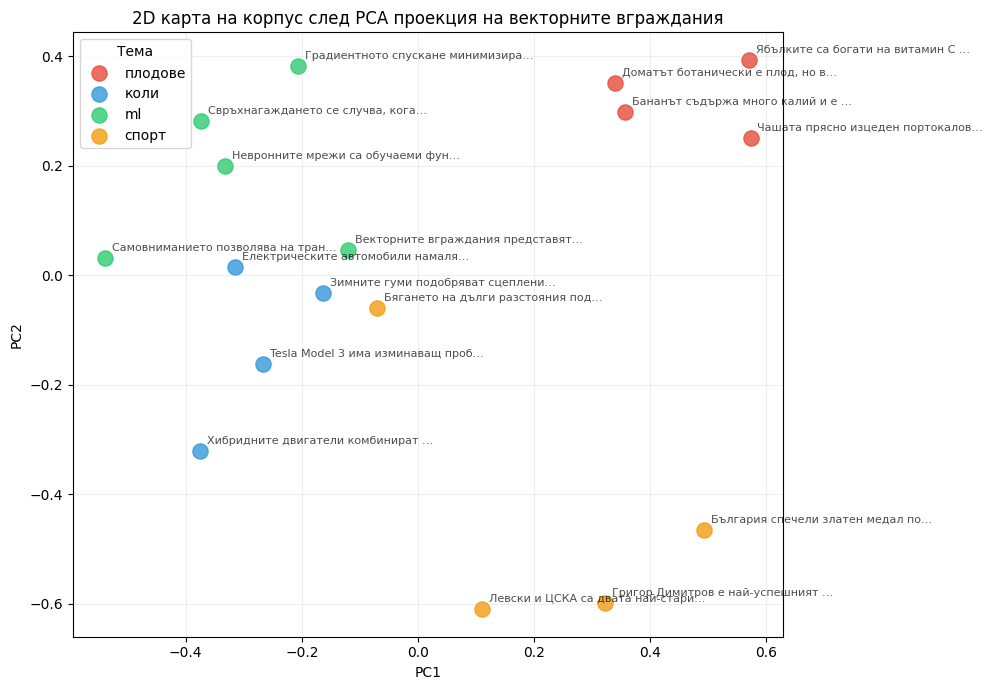

In [17]:
fig, ax = plt.subplots(figsize=(10, 7))
colors = {"плодове": "#E74C3C", "коли": "#3498DB", "ml": "#2ECC71", "спорт": "#F39C12"}
for label in set(labels):
    mask = [l == label for l in labels]
    pts = coords[mask]
    ax.scatter(pts[:, 0], pts[:, 1], c=colors[label], s=120, label=label, alpha=0.8)

# Кратък етикет до всяка точка
for (x, y), text in zip(coords, texts):
    short = text[:32] + ("…" if len(text) > 32 else "")
    ax.annotate(short, (x, y), fontsize=8, alpha=0.7,
                xytext=(5, 5), textcoords="offset points")

ax.set_title("2D карта на корпус след PCA проекция на векторните вграждания")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend(title="Тема")
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


### Изводи от Демо 2

- Векторното вграждане превръща смисъла на текст в **геометрия**.
- Темите се групират в клъстери дори без споделени ключови думи („бананът“ и „ябълките“ са близо, макар думите да са различни).
- PCA е загубна 2D проекция — добра за интуиция, но за реално търсене работим в пълните 384 измерения.
- Косинусовата близост дава число в [-1, 1], където 1 = идентичен смисъл.


---

## Демо 3: Един документ, три стратегии за разделяне

> Свързано със секцията **„↓ Тетрадка — Един документ, три стратегии“** в слайдовете.

**Цел:** Да видим колко силно стратегията за разделяне на части влияе върху извличането. Качеството на RAG често се решава тук, преди индекса.

Подход:

1. Един синтетичен markdown документ за курса (заглавия, секции, абзаци).
2. Три стратегии: фиксиран размер, фиксиран размер с припокриване, по markdown заглавия.
3. Едно и също запитване → top-3 части за всяка стратегия.


In [18]:
document = '''# Курс: От ГЕМ до агенти

## Регистрация и оценяване

Курсът се води в петък от 17:00 до 20:00 в зала 326. Регистрацията се извършва през университетската система. Крайният срок за регистрация е 20 февруари 2026 г.

Финалната оценка се формира от три теста и проект. Тестовете се провеждат на лекции номер 5, 9 и 14. Всеки тест носи 15 точки. Проектът носи 55 точки и се представя в последната лекция.

## Учебна програма

Лекциите покриват темите от въведение в машинното самообучение до агентни системи. Първите шест лекции изграждат основа: невронни мрежи, токенизация, трансформатори, дълъг контекст и предварително обучение.

Втората половина на курса е по-приложна: разсъждаващи модели, локални модели, халюцинации и RAG, и накрая агенти с инструменти. Проектните теми се обявяват в Лекция 9.

## Технически изисквания

Студентите трябва да имат Python 3.12 или по-нов. За работа с локални модели препоръчваме поне 8 GB RAM. Препоръчителен е инструментът `uv` за управление на зависимостите.

За домашните не са нужни графични карти. Тетрадките са оразмерени така, че да работят на лаптоп с MPS или CPU.

## Препоръчителна литература

Основните референции за курса включват „Speech and Language Processing“ от Jurafsky и Martin, оригиналния трансформатор статия „Attention Is All You Need“ и блога на Andrej Karpathy за neural networks.
'''
print(f"Документ: {len(document)} символа, {document.count(chr(10))} реда")


Документ: 1343 символа, 23 реда


In [19]:
def chunk_fixed(text, size=300):
    """Стратегия 1: разделяне на фиксирани блокове, без оглед на структура."""
    return [text[i:i + size] for i in range(0, len(text), size)]

def chunk_overlap(text, size=300, overlap=80):
    """Стратегия 2: фиксиран размер с припокриване."""
    step = size - overlap
    return [text[i:i + size] for i in range(0, len(text), step) if text[i:i + size]]

def chunk_by_headers(text):
    """Стратегия 3: разделяне по markdown заглавия от ниво ##."""
    parts = re.split(r"\n(?=## )", text)
    return [p.strip() for p in parts if p.strip()]


In [20]:
chunks_fixed = chunk_fixed(document, size=300)
chunks_overlap = chunk_overlap(document, size=300, overlap=80)
chunks_headers = chunk_by_headers(document)

print(f"Фиксиран размер: {len(chunks_fixed)} части (средно {int(sum(len(c) for c in chunks_fixed)/len(chunks_fixed))} символа)")
print(f"С припокриване:  {len(chunks_overlap)} части")
print(f"По заглавия:     {len(chunks_headers)} части (средно {int(sum(len(c) for c in chunks_headers)/len(chunks_headers))} символа)")


Фиксиран размер: 5 части (средно 268 символа)
С припокриване:  7 части
По заглавия:     5 части (средно 266 символа)


In [21]:
def top_k(query, chunks, k=3):
    """Връща top-k части по косинусова близост спрямо запитването."""
    q = embed(query)[0]
    cs = embed(chunks)
    scores = cs @ q  # векторите са нормализирани → скаларно произведение = косинус
    idx = np.argsort(-scores)[:k]
    return [(int(i), float(scores[i]), chunks[i]) for i in idx]


In [22]:
query = "Колко точки носи проектът и кога се представя?"

for name, ch in [("Фиксиран размер", chunks_fixed),
                 ("С припокриване", chunks_overlap),
                 ("По заглавия", chunks_headers)]:
    print(f"\n=== Стратегия: {name} ===")
    for rank, (idx, score, text) in enumerate(top_k(query, ch, k=2), 1):
        preview = text.replace("\n", " ")[:160]
        print(f"  [{rank}] score={score:.3f}  {preview}…")



=== Стратегия: Фиксиран размер ===
  [1] score=0.507  номер 5, 9 и 14. Всеки тест носи 15 точки. Проектът носи 55 точки и се представя в последната лекция.  ## Учебна програма  Лекциите покриват темите от въведение…
  [2] score=0.411  кст и предварително обучение.  Втората половина на курса е по-приложна: разсъждаващи модели, локални модели, халюцинации и RAG, и накрая агенти с инструменти. П…

=== Стратегия: С припокриване ===
  [1] score=0.500  лната оценка се формира от три теста и проект. Тестовете се провеждат на лекции номер 5, 9 и 14. Всеки тест носи 15 точки. Проектът носи 55 точки и се представя…
  [2] score=0.428  о-приложна: разсъждаващи модели, локални модели, халюцинации и RAG, и накрая агенти с инструменти. Проектните теми се обявяват в Лекция 9.  ## Технически изискв…

=== Стратегия: По заглавия ===
  [1] score=0.465  ## Регистрация и оценяване  Курсът се води в петък от 17:00 до 20:00 в зала 326. Регистрацията се извършва през университетската система. Крайният срок за

### Изводи от Демо 3

- **Фиксиран размер без припокриване** може да реже идея на две — отговорът се разпада между съседни части.
- **Припокриването** помага да не „изпуснем“ факт, който живее през граница, но увеличава индекса.
- **По заглавия** дава най-смислени единици, но изисква документът да има добра структура (markdown, секции).
- Една и съща заявка → различни top-k. **Лошото разделяне не може да се поправи с по-добър модел за генериране.**


---

## Демо 4: Точно търсене срещу приблизително (ANN)

> Свързано със секцията **„↓ Тетрадка — Точно търсене срещу ANN“** в слайдовете.

**Цел:** Да измерим компромиса скорост ↔ пълнота при много вектори.

Подход:

1. Генерираме ~10 000 синтетични вектора (384 измерения).
2. **Точно търсене:** brute-force със `numpy` — сравняваме всички вектори.
3. **ANN:** Chroma (използва HNSW индекс под капака).
4. Сравняваме време и recall.


In [23]:
rng = np.random.default_rng(42)
N, D = 10_000, 384

# Симулираме нормализирани вектори (като нашите embeddings)
synthetic = rng.standard_normal((N, D)).astype("float32")
synthetic /= np.linalg.norm(synthetic, axis=1, keepdims=True)

queries = rng.standard_normal((20, D)).astype("float32")
queries /= np.linalg.norm(queries, axis=1, keepdims=True)

print(f"Корпус: {N} вектора × {D} измерения")
print(f"Заявки: {queries.shape[0]}")


Корпус: 10000 вектора × 384 измерения
Заявки: 20


In [24]:
# Точно търсене — линейно сканиране на целия корпус
K = 10

start = time.perf_counter()
sims_exact = synthetic @ queries.T              # (N, num_queries)
topk_exact = np.argsort(-sims_exact, axis=0)[:K].T  # (num_queries, K)
exact_time = time.perf_counter() - start

print(f"Точно търсене: {exact_time*1000:.1f} ms за {len(queries)} заявки")
print(f"Време на заявка: {exact_time*1000/len(queries):.2f} ms")


Точно търсене: 30.1 ms за 20 заявки
Време на заявка: 1.51 ms


In [25]:
# ANN търсене с Chroma — клиент в памет, HNSW индекс
client = chromadb.EphemeralClient()

# # изчисти предишната колекция, ако съществува,
# # за да не се натрупват вектори при повторни изпълнения
# client.delete_collection("synthetic")

ann_col = client.create_collection(
    name="synthetic",
    metadata={"hnsw:space": "cosine"},
)

ids = [f"v{i}" for i in range(N)]
embeddings_list = synthetic.tolist()
max_batch_size = client.get_max_batch_size() if hasattr(client, "get_max_batch_size") else 5000

for start in range(0, len(ids), max_batch_size):
    end = start + max_batch_size
    ann_col.add(
        ids=ids[start:end],
        embeddings=embeddings_list[start:end],
    )

print(f"Използван размер на пакет: {max_batch_size}")
print(f"Индексирани вектори: {ann_col.count()}")


Използван размер на пакет: 5461
Индексирани вектори: 10000


In [26]:
start = time.perf_counter()
result = ann_col.query(query_embeddings=queries.tolist(), n_results=K)
ann_time = time.perf_counter() - start

print(f"ANN търсене: {ann_time*1000:.1f} ms за {len(queries)} заявки")
print(f"Време на заявка: {ann_time*1000/len(queries):.2f} ms")
print(f"Ускорение спрямо точното търсене: {exact_time/ann_time:.1f}x")


ANN търсене: 62.1 ms за 20 заявки
Време на заявка: 3.11 ms
Ускорение спрямо точното търсене: 0.5x


In [27]:
# Recall@10: колко от точните top-10 присъстват в ANN top-10?
ann_topk = np.array([[int(s[1:]) for s in row] for row in result["ids"]])

recalls = []
for exact_row, ann_row in zip(topk_exact, ann_topk):
    overlap = len(set(exact_row.tolist()) & set(ann_row.tolist()))
    recalls.append(overlap / K)

print(f"Recall@{K}: {np.mean(recalls):.3f}  (1.0 = ANN върна същите top-{K} като точното търсене)")


Recall@10: 0.460  (1.0 = ANN върна същите top-10 като точното търсене)


### Изводи от Демо 4

- При малък корпус (~10K) точното търсене все още е бързо — компромисът е силно изразен при милиони вектори.
- ANN индексите (HNSW тук) **жертват малко recall срещу голяма скорост**.
- Recall ~1.0 означава, че за повечето заявки ANN намира същите кандидати като точното търсене. Това е дизайнерска цел на HNSW.


---

## Демо 5: Ключови думи срещу семантично търсене (в Chroma)

> Свързано със секцията **„↓ Тетрадка — Ключови думи срещу семантика в Chroma“** в слайдовете.

**Цел:** Да видим кога TF-IDF (търсене по ключови думи) печели и кога губи спрямо векторното търсене.

Подход:

1. Малък корпус с реални и измислени правила и записи.
2. **TF-IDF** търсене с `scikit-learn`.
3. **Семантично търсене** в Chroma.
4. Запитвания, в които всеки подход бие другия.


In [28]:
support_corpus = [
    "Поръчка с номер 7842 беше изпратена с куриер Speedy на 12 май.",
    "За връщане на продукт се прилага 14-дневен срок съгласно европейското законодателство.",
    "Картовите плащания се обработват чрез борика и страйп.",
    "Кодът за отстъпка SPRING2026 е валиден до 31 май 2026 г.",
    "Доставката до адрес в София обикновено отнема 1-2 работни дни.",
    "Ако забравите паролата си, използвайте връзката „Забравена парола“ на началния екран.",
    "Безплатна доставка при поръчки над 50 лв. с куриер Еконт.",
    "Продуктите с течности не могат да се изпращат с авиокуриер.",
    "Гаранцията на електрониката е 24 месеца от датата на покупка.",
    "Кодът IBAN на фирмата е BG80UNCR70001234567890.",
]
print(f"Документи: {len(support_corpus)}")


Документи: 10


In [29]:
# Подготвяме TF-IDF индекс
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(support_corpus)
print(f"TF-IDF матрица: {tfidf_matrix.shape}  (документи × термини)")


TF-IDF матрица: (10, 76)  (документи × термини)


In [30]:
# Подготвяме семантичен индекс в Chroma
sem_client = chromadb.EphemeralClient()

# # изчисти предишната колекция, ако съществува,
# # за да не се натрупват вектори при повторни изпълнения
# sem_client.delete_collection("support")

sem_col = sem_client.create_collection(
    name="support",
    metadata={"hnsw:space": "cosine"},
)
sem_ids = [f"d{i}" for i in range(len(support_corpus))]
sem_embeddings = embed(support_corpus).tolist()
sem_max_batch_size = sem_client.get_max_batch_size() if hasattr(sem_client, "get_max_batch_size") else 5000

for start in range(0, len(sem_ids), sem_max_batch_size):
    end = start + sem_max_batch_size
    sem_col.add(
        ids=sem_ids[start:end],
        embeddings=sem_embeddings[start:end],
        documents=support_corpus[start:end],
    )
print(f"Индексирани документи: {sem_col.count()}")


Индексирани документи: 10


In [31]:
def search_keywords(query, k=2):
    qv = tfidf.transform([query])
    scores = (tfidf_matrix @ qv.T).toarray().ravel()
    idx = np.argsort(-scores)[:k]
    return [(int(i), float(scores[i]), support_corpus[i]) for i in idx if scores[i] > 0]

def search_semantic(query, k=2):
    res = sem_col.query(query_embeddings=embed(query).tolist(), n_results=k)
    out = []
    for doc_id, doc, dist in zip(res["ids"][0], res["documents"][0], res["distances"][0]):
        out.append((doc_id, 1 - dist, doc))  # cosine distance → similarity
    return out


In [32]:
def compare(query):
    print(f"\nЗапитване: „{query}“")
    print("  Ключови думи (TF-IDF):")
    for _, score, text in search_keywords(query):
        print(f"    [{score:.3f}] {text}")
    print("  Семантично (Chroma):")
    for _, score, text in search_semantic(query):
        print(f"    [{score:.3f}] {text}")


**Случай 1 — точно име/номер:** ключовите думи трябва да са победители.


In [33]:
compare("Каква е поръчка 7842?")



Запитване: „Каква е поръчка 7842?“
  Ключови думи (TF-IDF):
    [0.477] Поръчка с номер 7842 беше изпратена с куриер Speedy на 12 май.
  Семантично (Chroma):
    [0.667] Поръчка с номер 7842 беше изпратена с куриер Speedy на 12 май.
    [0.405] Кодът IBAN на фирмата е BG80UNCR70001234567890.


In [34]:
compare("Какъв е IBAN на фирмата?")



Запитване: „Какъв е IBAN на фирмата?“
  Ключови думи (TF-IDF):
    [0.760] Кодът IBAN на фирмата е BG80UNCR70001234567890.
    [0.159] Гаранцията на електрониката е 24 месеца от датата на покупка.
  Семантично (Chroma):
    [0.704] Кодът IBAN на фирмата е BG80UNCR70001234567890.
    [0.225] Безплатна доставка при поръчки над 50 лв. с куриер Еконт.


**Случай 2 — перефразиране:** семантичното търсене познава смисъла дори когато думите са различни.


In [35]:
compare("Как да си върна стоката?")



Запитване: „Как да си върна стоката?“
  Ключови думи (TF-IDF):
    [0.257] Продуктите с течности не могат да се изпращат с авиокуриер.
    [0.220] Ако забравите паролата си, използвайте връзката „Забравена парола“ на началния екран.
  Семантично (Chroma):
    [0.307] Картовите плащания се обработват чрез борика и страйп.
    [0.301] За връщане на продукт се прилага 14-дневен срок съгласно европейското законодателство.


In [36]:
compare("За колко време стига пратката в столицата?")



Запитване: „За колко време стига пратката в столицата?“
  Ключови думи (TF-IDF):
    [0.303] Кодът за отстъпка SPRING2026 е валиден до 31 май 2026 г.
    [0.261] За връщане на продукт се прилага 14-дневен срок съгласно европейското законодателство.
  Семантично (Chroma):
    [0.429] Доставката до адрес в София обикновено отнема 1-2 работни дни.
    [0.407] За връщане на продукт се прилага 14-дневен срок съгласно европейското законодателство.


### Изводи от Демо 5

| Силно при… | Ключови думи (TF-IDF, BM25) | Семантично търсене |
|------------|-----------------------------|--------------------|
| Точни имена, номера, IBAN, кодове | ✅ | ❌ |
| Перефразиране, синоними, друг език | ❌ | ✅ |
| Редки термини и съкращения | ✅ | смесено |
| Когато думите изобщо не съвпадат | ❌ | ✅ |

В реална система често се прави **хибридно търсене**: и двата сигнала, последвани от пренареждане. Тук не го реализираме, но в продукция това е стандартен дизайн.


---

## Демо 6: RAG система от край до край

> Свързано със секцията **„↓ Тетрадка — RAG от край до край“** в слайдовете.

**Цел:** Свързваме всички компоненти и сравняваме **с RAG** срещу **без RAG** върху един и същ корпус от Иван Вазов.

Стъпки:

1. Зареждане и кратко изрязване на корпуса.
2. Разделяне на части (по абзаци).
3. Векторни вграждания и индекс в Chroma.
4. Извличане на top-k за дадено запитване.
5. Сглобяване на подкана с контекст и цитати.
6. Генериране — без и с RAG.
7. Failure case: лошо извличане → уверен, но грешен отговор.


In [37]:
DATA_PATH = Path("../../data/ivan_vazov.txt")
raw_text = DATA_PATH.read_text(encoding="utf-8")
print(f"Заредени символи: {len(raw_text):,}")
print("Начало:", repr(raw_text[:120]))


Заредени символи: 3,990,245
Начало: '\ufeff\tИван Вазов\n\tДраски и шарки\n\n\tI част\n\tУкрасил столицата\n\n\tВсеки, който го познаваше преди две години, помни как беше съ'


In [38]:
def chunk_paragraphs(text, min_len=120, max_len=800):
    """В корпуса всеки абзац е на свой ред. Чистим и групираме по дължина."""
    raw_parts = [p.strip() for p in text.split("\n") if p.strip()]
    chunks = []
    for p in raw_parts:
        if len(p) < min_len:
            continue                          # пропускаме много къси редове („* * *“, заглавия)
        if len(p) <= max_len:
            chunks.append(p)
        else:
            for i in range(0, len(p), max_len):
                chunks.append(p[i:i + max_len])
    return chunks

chunks = chunk_paragraphs(raw_text)
print(f"Получени части: {len(chunks)}")
print(f"Средна дължина: {int(np.mean([len(c) for c in chunks]))} символа")
print("\nПървата част (началото):")
print(chunks[0][:300], "…")


Получени части: 7693
Средна дължина: 332 символа

Първата част (началото):
Всеки, който го познаваше преди две години, помни как беше съвсем други човек господин Бучински: лек, приятен и весел, винаги в добро разположение на духа, което имаше заразително действие въз другите. Той търсеше тогава обществото, което също го търсеше; интересуваха го всичките новини градски и вс …


In [39]:
# Индексираме в Chroma с метаданни — номер на частта за цитиране
rag_client = chromadb.EphemeralClient()

# изчисти предишната колекция, ако съществува,
# за да не се натрупват вектори при повторни изпълнения
# rag_client.delete_collection("vazov")

rag_col = rag_client.create_collection(
    name="vazov", metadata={"hnsw:space": "cosine"},
)
rag_ids = [f"c{i}" for i in range(len(chunks))]
rag_embeddings = embed(chunks).tolist()
rag_metadatas = [{"chunk_id": i} for i in range(len(chunks))]
rag_max_batch_size = rag_client.get_max_batch_size() if hasattr(rag_client, "get_max_batch_size") else 5000

for start in range(0, len(rag_ids), rag_max_batch_size):
    end = start + rag_max_batch_size
    rag_col.add(
        ids=rag_ids[start:end],
        embeddings=rag_embeddings[start:end],
        documents=chunks[start:end],
        metadatas=rag_metadatas[start:end],
    )
print(f"Индексирани части: {rag_col.count()}")


Индексирани части: 7693


In [40]:
def retrieve(query, k=3):
    """Връща top-k части от корпуса с техните идентификатори."""
    res = rag_col.query(query_embeddings=embed(query).tolist(), n_results=k)
    out = []
    for doc, meta, dist in zip(res["documents"][0], res["metadatas"][0], res["distances"][0]):
        out.append({"chunk_id": meta["chunk_id"], "score": 1 - dist, "text": doc})
    return out


In [41]:
RAG_SYSTEM_PROMPT = """Ти си асистент за въпроси върху творчеството на Иван Вазов.
Отговори само на базата на КОНТЕКСТА по-долу.
Ако отговорът не присъства в контекста, кажи: „Не знам.“.
Цитирай номерата на използваните откъси в скоби, например [#3]."""

def build_rag_prompt(question, retrieved):
    context = "\n\n".join(
        f"[#{r['chunk_id']}] {r['text']}" for r in retrieved
    )
    return f"КОНТЕКСТ:\n{context}\n\nВЪПРОС:\n{question}\n"

### 6.1 Без RAG — моделът отговаря „от памет“


In [42]:
question = "Колко етажа имаше новата къща на господин Бучински?"


print("=== БЕЗ RAG ===")
print(generate(question, max_new_tokens=180, temperature=0.3))


=== БЕЗ RAG ===
Я не можу да използвам информации о конкретните места или дати, така как също не се заслужва правилно доступ от обоят. Може да се използват следният пример за да ви помогнете:

"Бучински - близкото назване на Господина Бучински, което се извършва в града "Бучинск", на Северна Кавказия. Нека се използва като пример за да ви помогне да изведете количества этажей на новата къща."

Тук се изпълнява информация о няколко градове и насел


**Очаквано:** малкият модел или измисля сюжет, или казва нещо съвсем общо за герой с такова име. Той не е чел разказа.


### 6.2 С RAG — извличане → сглобяване → генериране


In [43]:
retrieved = retrieve(question, k=3)
for r in retrieved:
    print(f"[#{r['chunk_id']}] score={r['score']:.3f}  {r['text'][:140]}…\n")


[#3] score=0.814  Господин Бучински има… има… — нека да кажа смело — има нова къща на три ката, или триетажна, както се изразяват учено софиянците.…

[#6614] score=0.655  Той бе въведен на горния кат, в чиста стаичка, постлана с нови черги и с българска покъщнина по полиците, с бели завеси по прозорците.…

[#3134] score=0.587  В едната стаичка на това здание, което сега изглеждаше необитаемо, Дебрянски беше имал жилището си през времето, когато живееше в селото. То…



In [44]:
rag_prompt = build_rag_prompt(question, retrieved)
print("=== С RAG ===")
print(generate(rag_prompt, system_message=RAG_SYSTEM_PROMPT,
               max_new_tokens=220, temperature=0.3))


=== С RAG ===
Той има нова къща на три ката.


**Очаквано:** отговорът стъпва върху извлечените абзаци и носи номера на цитати. Това позволява проверка от човек.


### 6.3 Failure case: правилно извличане, грешен въпрос

Какво става, ако зададем въпрос, на който корпусът няма как да отговори?


In [45]:
off_topic = "Каква е официалната валута на Япония?"
retrieved = retrieve(off_topic, k=3)

print("Top-3 извлечени части (нерелевантни на въпроса):")
for r in retrieved:
    print(f"  [#{r['chunk_id']}] score={r['score']:.3f}  {r['text'][:100]}…")

print("\n=== Отговор на модела ===")
rag_prompt = build_rag_prompt(off_topic, retrieved)
print(generate(rag_prompt, system_message=RAG_SYSTEM_PROMPT,
               max_new_tokens=120, temperature=0.3))


Top-3 извлечени части (нерелевантни на въпроса):
  [#6396] score=0.424  Той мисли, че могат както щат шовинистите да прославят Япония за цивилизацията й и напредъка й — тя …
  [#6393] score=0.387  „Омърси се великата наша земя от един срам! Бездарният и глупав стихоплет, именуем Гехайша Тцузе, ни…
  [#6376] score=0.384  И в тоя час това същото говореха в Йокохама, в Нагасаки, в Йезо, в Симоносеки и във всичките остали …

=== Отговор на модела ===
Даниякър


**Какво гледаме:** Подканата изрично инструктира модела да каже „Не знам“, когато контекстът не съдържа отговор. Малките модели често нарушават това правило. Това е знак, че RAG не е автоматична гаранция за вярност — подканата и моделът също са част от системата.

### Изводи от Демо 6

- Един и същ модел дава качествено различен отговор с и без релевантен контекст.
- Цитатите по номера на части правят отговора **проверим**.
- RAG не премахва халюцинациите — премества проблема от „коя информация е в теглата“ към „каква информация подаваме“.


---

## Демо 7: Оценка на качеството и debugging

> Свързано със секцията **„↓ Тетрадка — Оценка на качеството и debugging“** в слайдовете.

**Цел:** Да измерим качеството по компоненти и да приложим debugging рамката върху конкретен грешен отговор.

Подход:

1. Малък **golden set** от въпроси с очаквани идентификатори на части.
2. Метрики за извличане: **Precision@k**, **Recall@k**.
3. Debugging walkthrough на 5 стъпки.


In [46]:
# Намираме реални chunk_id за известни ключови думи в корпуса — така изграждаме „истината“
def find_chunks_containing(keyword):
    return [i for i, c in enumerate(chunks) if keyword.lower() in c.lower()]

print("Бучински се споменава в части:", find_chunks_containing("Бучински"))
print("Кочов се споменава в части:   ", find_chunks_containing("Кочов"))
print("Божанка се споменава в части: ", find_chunks_containing("Божанка"))


Бучински се споменава в части: [0, 1, 3, 5, 6, 7]
Кочов се споменава в части:    [8, 9, 13, 15]
Божанка се споменава в части:  [10, 12, 13, 14, 15, 16, 17, 19, 25, 26, 27]


In [47]:
# Golden set: за всеки въпрос — кои части ТРЯБВА да се извлекат
golden = [
    {
        "q": "Защо господин Бучински се чувстваше нещастен?",
        "expected": set(find_chunks_containing("Бучински")),
    },
    {
        "q": "Какво направи Бучински с новата си къща?",
        "expected": set(find_chunks_containing("Бучински")),
    },
    {
        "q": "Защо Димитър Кочов се притеснява за жена си?",
        "expected": set(find_chunks_containing("Кочов")) | set(find_chunks_containing("Божанка")),
    },
]
for item in golden:
    print(f"  „{item['q']}“  →  {len(item['expected'])} очаквани части")


  „Защо господин Бучински се чувстваше нещастен?“  →  6 очаквани части
  „Какво направи Бучински с новата си къща?“  →  6 очаквани части
  „Защо Димитър Кочов се притеснява за жена си?“  →  13 очаквани части


In [48]:
def precision_at_k(retrieved_ids, expected):
    if not retrieved_ids:
        return 0.0
    hits = sum(1 for i in retrieved_ids if i in expected)
    return hits / len(retrieved_ids)

def recall_at_k(retrieved_ids, expected):
    if not expected:
        return 0.0
    hits = sum(1 for i in retrieved_ids if i in expected)
    return hits / len(expected)


In [49]:
K = 5
rows = []
for item in golden:
    retrieved = retrieve(item["q"], k=K)
    ids = [r["chunk_id"] for r in retrieved]
    p = precision_at_k(ids, item["expected"])
    r = recall_at_k(ids, item["expected"])
    rows.append((item["q"], p, r, ids))

print(f"{'Въпрос':<55} {'P@5':>5} {'R@5':>5}")
print("-" * 70)
for q, p, r, _ in rows:
    print(f"{q[:54]:<55} {p:>5.2f} {r:>5.2f}")

mean_p = np.mean([r[1] for r in rows])
mean_r = np.mean([r[2] for r in rows])
print("-" * 70)
print(f"{'Средно':<55} {mean_p:>5.2f} {mean_r:>5.2f}")


Въпрос                                                    P@5   R@5
----------------------------------------------------------------------
Защо господин Бучински се чувстваше нещастен?            0.20  0.17
Какво направи Бучински с новата си къща?                 0.60  0.50
Защо Димитър Кочов се притеснява за жена си?             0.00  0.00
----------------------------------------------------------------------
Средно                                                   0.27  0.22


### 7.1 Debugging walkthrough

Когато RAG отговорът е грешен, минаваме по 5 въпроса в строг ред — поправяме **първата** счупена стъпка, не последния симптом.


In [50]:
def debug_question(question, expected_ids, k=5):
    print(f"Въпрос: „{question}“\n")

    # 1. Има ли изобщо факта в корпуса?
    print("1) Има ли правилните части в корпуса?")
    if expected_ids:
        print(f"   ✓ Да — части {sorted(expected_ids)}")
    else:
        print("   ✗ Не — проблемът е в данните.")
        return

    # 2. Разделянето запази ли факта в полезна част?
    print("\n2) Разделянето запази ли факта смислено?")
    sample = chunks[next(iter(expected_ids))]
    print(f"   Дължина на първата очаквана част: {len(sample)} символа")

    # 3. Извлича ли се правилната част?
    print("\n3) Извлича ли модулът за извличане правилните части?")
    retrieved = retrieve(question, k=k)
    ids = [r["chunk_id"] for r in retrieved]
    print(f"   Top-{k} извлечени: {ids}")
    overlap = set(ids) & expected_ids
    if overlap:
        print(f"   ✓ Има застъпване: {sorted(overlap)}")
    else:
        print("   ✗ Няма застъпване — проблемът е във векторните вграждания, top_k или заявката.")

    # 4. Попада ли частта в подканата?
    print("\n4) Сглобяваме ли подкана с тези части?")
    prompt = build_rag_prompt(question, retrieved)
    print(f"   ✓ Дължина на подканата: {len(prompt)} символа")

    # 5. Следва ли моделът контекста?
    print("\n5) Отговор на модела:")
    answer = generate(prompt, system_message=RAG_SYSTEM_PROMPT,
                      max_new_tokens=180, temperature=0.3)
    print(f"   {answer}")


In [51]:
# Пример с подходящ въпрос
debug_question(
    "Какво направи господин Бучински, за да реши проблема с къщата?",
    set(find_chunks_containing("Бучински")),
    k=3,
)


Въпрос: „Какво направи господин Бучински, за да реши проблема с къщата?“

1) Има ли правилните части в корпуса?
   ✓ Да — части [0, 1, 3, 5, 6, 7]

2) Разделянето запази ли факта смислено?
   Дължина на първата очаквана част: 402 символа

3) Извлича ли модулът за извличане правилните части?
   Top-3 извлечени: [3, 4834, 3431]
   ✓ Има застъпване: [3]

4) Сглобяваме ли подкана с тези части?
   ✓ Дължина на подканата: 1314 символа

5) Отговор на модела:
   Господин Бучински има нова къща на три ката, или триетажна, както се изразяват учено софиянците.


### Изводи от Демо 7

- **Не смесвай качеството на извличането с качеството на генерирането.** Една обща оценка „отговорът ми харесва“ скрива къде е повредата.
- **Малък golden set + Precision@k и Recall@k** дава бърза обратна връзка при промени (различен размер на части, друг top_k, друг модел).
- Debugging върви по реда: **корпус → разделяне → извличане → подкана → модел**. Поправя се **първата** счупена стъпка.


---

## Обобщение

- Малки локални модели халюцинират **уверено** — точно това ги прави добри експонати за демонстрация на проблема.
- Векторното вграждане превръща смисъла в геометрия; семантичното търсене работи дори без споделени думи.
- Стратегията за разделяне на части определя какво изобщо може да се извлече. Качеството на RAG често се решава тук.
- ANN индекси (HNSW) жертват малко recall срещу голяма скорост — за повечето системи това е добрият компромис.
- Хибридното търсене е практическа реалност: ключови думи и семантика се допълват.
- RAG не премахва халюцинациите; превръща ги в **проблем на извличането и подканата**, който може да се измерва и поправя.
- Оценявай RAG по компоненти: качество на корпус, на извличане, на подкана и на генериране — поотделно.
